<a href="https://colab.research.google.com/github/russel11h/Rearning-rate-in-ANN/blob/main/Basic_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from copy import deepcopy
import numpy as np
inputs = np.array([[1,1]])
outputs = np.array([[0]])
weights = [
    np.array([
        [-0.0053,.3793],
        [-0.5820,-0.5204],
        [-0.2723,0.1896]], dtype=np.float32).T,
    np.array([-0.0140,0.5607,-0.0628], dtype=np.float32),
    np.array([[0.1528,-0.1745,-0.1135]],dtype=np.float32).T,
    np.array([-0.5516],dtype=np.float32)
]

In [ ]:
def feed_forward(inputs, outputs, weights):
  pre_hidden = np.dot(inputs,weights[0]) + weights[1] #weight[1] is the bias term
  hidden = 1/(1+np.exp(-pre_hidden))
  pred_out = np.dot(hidden,weights[2]) + weights[3]   #weight[3] is the bias value
  mse = np.mean(np.square(pred_out - outputs))
  return mse

In [ ]:
def update_weights(inputs, outputs, weights, lr):
  org_wt = deepcopy(weights)
  temp_wt = deepcopy(weights)
  up_wt = deepcopy(weights)

  org_loss = feed_forward(inputs,outputs,weights)

  for i, layer in enumerate(org_wt):
    for index, wt in np.ndenumerate(layer):
      temp_wt = deepcopy(weights)
      temp_wt[i][index] += .0001
      _loss_plus = feed_forward(inputs,outputs,temp_wt)
      grad = (_loss_plus - org_loss)/(.0001)
      up_wt[i][index] -= grad*lr

  return up_wt, org_loss

Text(0, 0.5, 'Loss value')

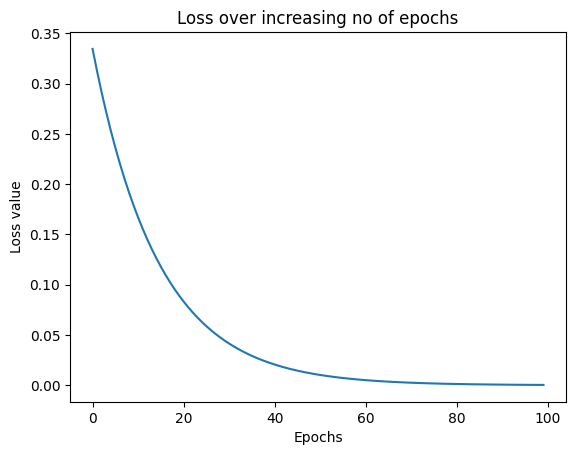

In [ ]:
losses = []
epochs = 100
for epoch in range(epochs):
  weights, loss = update_weights(inputs,outputs,weights,0.01)
  losses.append(loss)

import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(losses)
plt.title('Loss over increasing no of epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss value')

In [ ]:
pre_hidden = np.dot(inputs,weights[0]) + weights[1]
hidden = 1/(1+np.exp(-pre_hidden))
pred_out = np.dot(hidden,weights[2])+weights[3]
print(pred_out)

[[-0.0174781]]
